# Atrial Fibrillation Detection from PPG
This notebook now uses a Python-only preprocessing pipeline for loading, filtering, visualizing, segmenting, and training on PPG data.

## 1. Setup And Imports
This section imports the shared preprocessing helpers, plotting tools, and model-building libraries used throughout the workflow.

In [1]:
# Imports
from pathlib import Path
import os

import matplotlib.pyplot as plt
import joblib
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

from ppg_pipeline import (
    detect_beats,
    get_recording_label,
    get_recording_fs,
    get_recording_signal,
    load_mimic_perform_csv_dataset,
    plot_signal_overview,
    plot_windows,
    preprocess_ppg,
    segment_signal,
)

print(os.getcwd())


d:\Project Repos\PPG-Arrhythmia-Detection\code


## 2. Explore One Recording
This section loads the CSV-based dataset, picks one example recording, applies preprocessing, detects peaks, and visualizes both the full signal and a few segmented windows.

Records loaded: 35
Data root: d:\Project Repos\PPG-Arrhythmia-Detection\data
Labels CSV: d:\Project Repos\PPG-Arrhythmia-Detection\data\record_labels.csv
Example sampling rate: 125 Hz
Example beats detected: 83
Example IBIs computed: 82
Example windows generated: 478


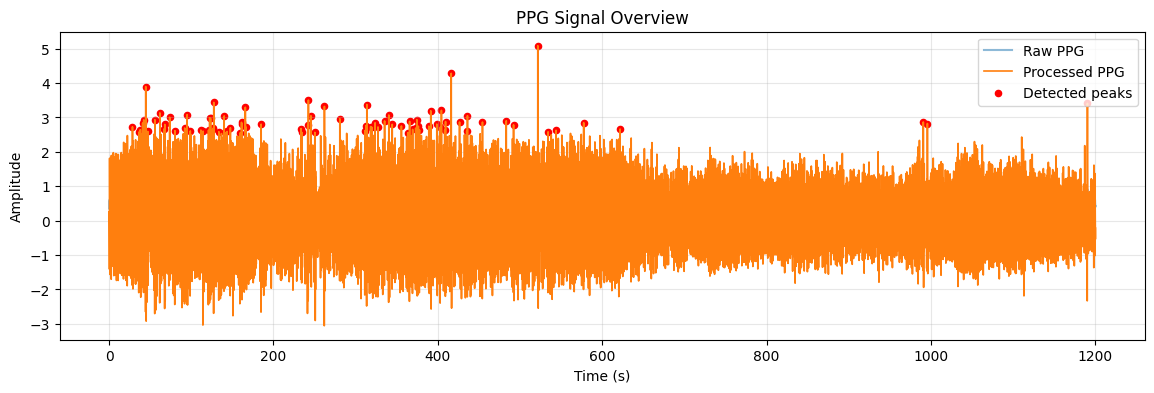

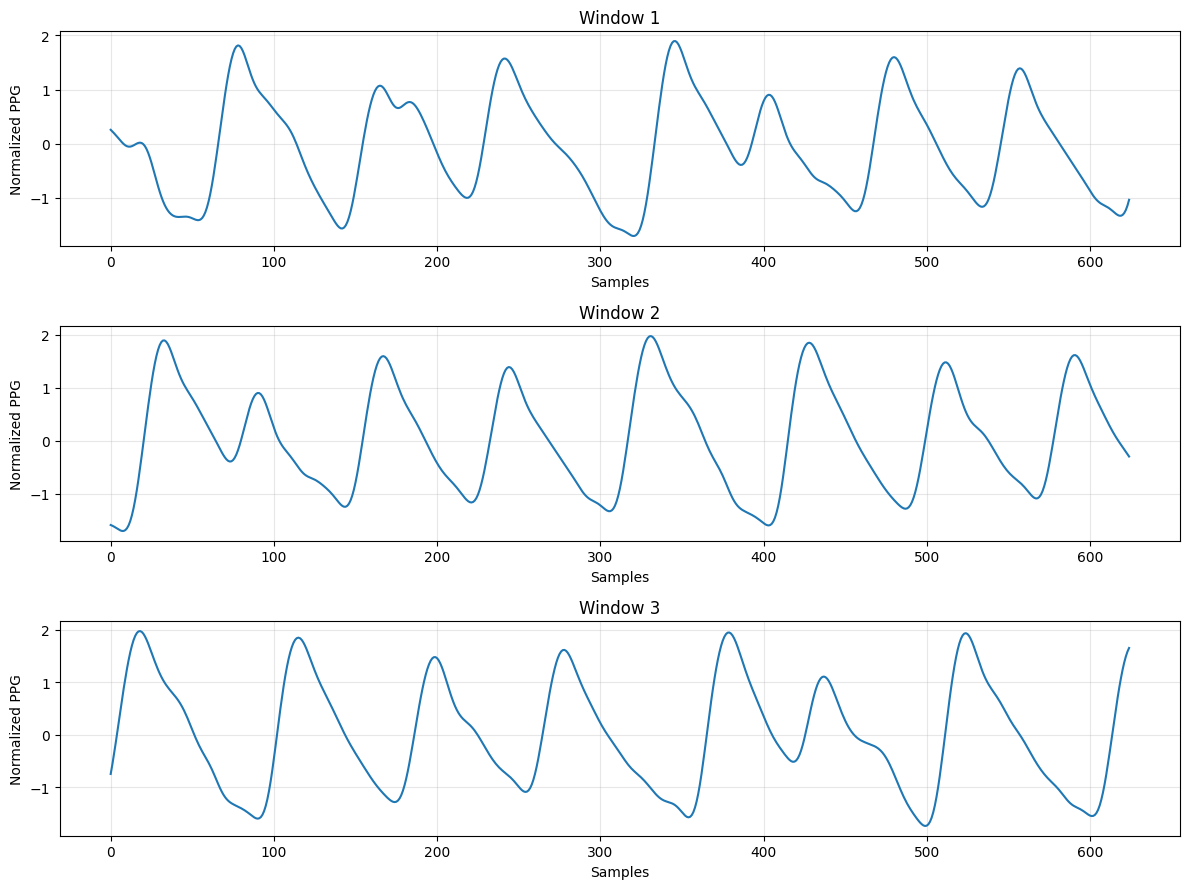

In [2]:
# Load raw dataset, preprocess one recording, and visualize the signal pipeline
DATA_ROOT = Path.cwd().parent / 'data'
LABELS_PATH = Path.cwd().parent / 'data' / 'record_labels.csv'
records = load_mimic_perform_csv_dataset(DATA_ROOT)

record_index = 0
record = records[record_index]
fs = get_recording_fs(record)
ppg_raw = get_recording_signal(record)
ppg_proc = preprocess_ppg(ppg_raw, fs=fs)
peaks, ibi, _ = detect_beats(ppg_proc, fs=fs)
example_windows = segment_signal(ppg_proc, fs=fs)

print(f'Records loaded: {len(records)}')
print(f'Data root: {DATA_ROOT}')
print(f'Labels CSV: {LABELS_PATH}')
print(f'Example sampling rate: {fs} Hz')
print(f'Example beats detected: {len(peaks)}')
print(f'Example IBIs computed: {len(ibi)}')
print(f'Example windows generated: {len(example_windows)}')

plot_signal_overview(ppg_raw, ppg_proc, fs=fs, peaks=peaks)
plt.show()

plot_windows(example_windows, max_windows=3)
plt.show()

## 3. Build The Training Dataset
Here we load labels, preprocess every recording, split each signal into fixed-length windows, and create the final feature matrix `X_windows` and label vector `y`.

In [3]:
# Build record-level metadata first, not window-level labels.
# This is important because we want to split by RECORD, then create windows separately for train and test.
record_labels = np.array([get_recording_label(record) for record in records], dtype=int)
record_sources = [record.get("source_path", f"record_{idx}") for idx, record in enumerate(records)]

# Save the record metadata so the mapping is visible outside the notebook too.
labels_df = pd.DataFrame({
    'record_index': np.arange(len(records)),
    'label': record_labels,
    'source_path': record_sources,
})
labels_df.to_csv(LABELS_PATH, index=False)

print('Saved record metadata to:', LABELS_PATH)
print(labels_df['label'].value_counts().sort_index())
print(labels_df.head())

# Split by record ID so that windows from the same source record do not leak into both train and test.
record_indices = np.arange(len(records))
train_record_ids, test_record_ids = train_test_split(
    record_indices,
    test_size=0.2,
    random_state=42,
    stratify=record_labels,
)

print("Train records:", len(train_record_ids), "Test records:", len(test_record_ids))
print("Train record labels:", np.bincount(record_labels[train_record_ids]))
print("Test record labels:", np.bincount(record_labels[test_record_ids]))


Saved record metadata to: d:\Project Repos\PPG-Arrhythmia-Detection\data\record_labels.csv
label
0    16
1    19
Name: count, dtype: int64
   record_index  label                                        source_path
0             0      1  d:\Project Repos\PPG-Arrhythmia-Detection\data...
1             1      1  d:\Project Repos\PPG-Arrhythmia-Detection\data...
2             2      1  d:\Project Repos\PPG-Arrhythmia-Detection\data...
3             3      1  d:\Project Repos\PPG-Arrhythmia-Detection\data...
4             4      1  d:\Project Repos\PPG-Arrhythmia-Detection\data...
Train records: 28 Test records: 7
Train record labels: [13 15]
Test record labels: [3 4]


## 4. Prepare And Train The LSTM Baseline
The windows are standardized, reshaped to `(samples, timesteps, features)`, and passed into a small LSTM baseline. We keep this section for comparison, but the Random Forest later in the notebook is the stronger practical model for this dataset.

In [4]:
# Build train/test windows AFTER the record split.
# This avoids leakage from overlapping windows of the same record appearing in both sets.
def build_windows_for_record_ids(record_id_list):
    X_list = []
    y_list = []
    window_record_ids = []
    for idx in record_id_list:
        record = records[idx]
        fs = get_recording_fs(record)
        signal = preprocess_ppg(get_recording_signal(record), fs=fs)
        windows = segment_signal(signal, fs=fs)
        if len(windows) == 0:
            continue
        label = get_recording_label(record)
        X_list.append(windows)
        y_list.extend([label] * len(windows))
        window_record_ids.extend([idx] * len(windows))
    if not X_list:
        raise ValueError("No windows were generated for the provided record IDs.")
    X = np.vstack(X_list)
    y = np.array(y_list, dtype=int)
    return X, y, np.array(window_record_ids, dtype=int)

X_train_windows, y_train, train_window_record_ids = build_windows_for_record_ids(train_record_ids)
X_test_windows, y_test, test_window_record_ids = build_windows_for_record_ids(test_record_ids)

# Fit the scaler on TRAIN ONLY, then transform test with the same fitted scaler.
# This prevents the test set from leaking information into preprocessing.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_windows)
X_test_scaled = scaler.transform(X_test_windows)

# LSTM expects shape: (samples, timesteps, features).
X_train = np.expand_dims(X_train_scaled, axis=2)
X_test = np.expand_dims(X_test_scaled, axis=2)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('Train window class balance:', np.bincount(y_train))
print('Test window class balance:', np.bincount(y_test))


X_train shape: (13384, 625, 1)
X_test shape: (3346, 625, 1)
y_train shape: (13384,)
y_test shape: (3346,)
Train window class balance: [6214 7170]
Test window class balance: [1434 1912]


In [5]:
# Compute class weights from TRAIN labels only.
# This helps if AF / non-AF windows are not perfectly balanced after the record split.
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, class_weights))
print('Class weights:', class_weight)


Class weights: {np.int64(0): np.float64(1.0769230769230769), np.int64(1): np.float64(0.9333333333333333)}


In [6]:
# Build a slightly stronger LSTM baseline.
# Change 1: use two LSTM layers instead of one.
# Change 2: reduce the hidden sizes a bit so CPU training stays manageable.
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 625, 32)        │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,777 (30.38 KB)

 Trainable params: 7,777 (30.38 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train with early stopping and class weights.
# Change 3: EarlyStopping prevents wasting epochs once validation stops improving.
# Change 4: class_weight helps if one class is underrepresented.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1,
)


Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 107s 608ms/step - accuracy: 0.5074 - loss: 0.6930 - val_accuracy: 0.2858 - val_loss: 0.7248
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 92s 549ms/step - accuracy: 0.5103 - loss: 0.6918 - val_accuracy: 0.2888 - val_loss: 0.7489
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 102s 607ms/step - accuracy: 0.5295 - loss: 0.6890 - val_accuracy: 0.2880 - val_loss: 0.7114
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 153s 666ms/step - accuracy: 0.5135 - loss: 0.6927 - val_accuracy: 0.2861 - val_loss: 0.7379
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 95s 569ms/step - accuracy: 0.5118 - loss: 0.6919 - val_accuracy: 0.2869 - val_loss: 0.7463
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 91s 543ms/step - accuracy: 0.5264 - loss: 0.6890 - val_accuracy: 0.4632 - val_loss: 0.7403


## 5. Evaluate And Save The LSTM Baseline
This section measures performance on the held-out record split, prints detailed classification metrics, visualizes the confusion matrix, explains a few predictions with SHAP, and saves the LSTM baseline for comparison.

In [8]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.3f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.4289 - loss: 0.7003
Test Accuracy: 0.429


### Classification Metrics
This section converts model probabilities into binary AF predictions, prints a classification report, and visualizes the confusion matrix on the test set.

Classification Report:
              precision    recall  f1-score   support

      Non-AF       0.43      1.00      0.60      1434
          AF       0.60      0.00      0.00      1912

    accuracy                           0.43      3346
   macro avg       0.51      0.50      0.30      3346
weighted avg       0.53      0.43      0.26      3346



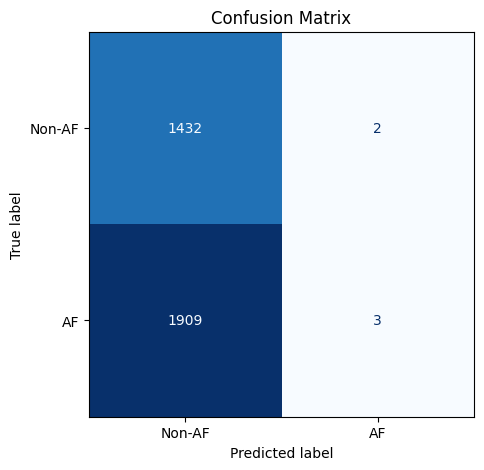

In [9]:
# Classification report and confusion matrix
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-AF', 'AF'], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-AF', 'AF'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')
plt.show()


### SHAP Explanation For The LSTM Baseline
This section uses SHAP to estimate which timesteps in a PPG window contributed most to the LSTM baseline's AF prediction. For sequence models, this is best treated as a local explanation rather than a global physiological truth.

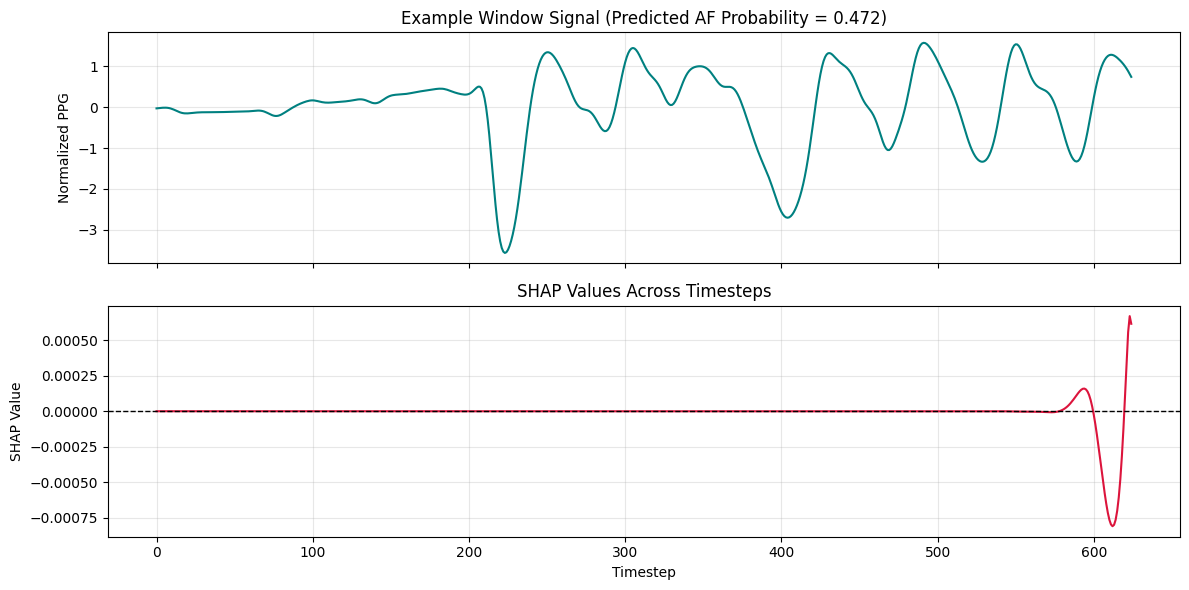

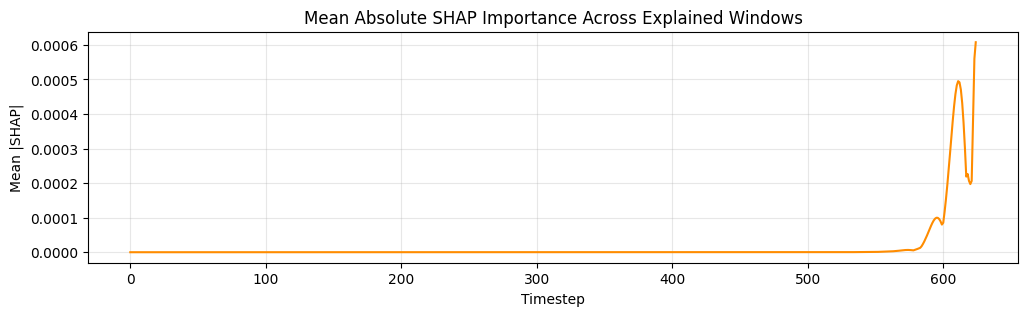

In [10]:
# SHAP explanation for a small set of test windows
background_size = min(64, len(X_train))
explain_size = min(3, len(X_test))
background = X_train[:background_size]
X_explain = X_test[:explain_size]

background = np.asarray(background, dtype=np.float32)
X_explain = np.asarray(X_explain, dtype=np.float32)

explainer = shap.GradientExplainer((model.inputs, model.outputs[0]), background)
shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
if shap_values.ndim == 4:
    shap_values = shap_values[..., 0]

sample_idx = 0
sample_signal = X_explain[sample_idx, :, 0]
sample_shap = shap_values[sample_idx, :, 0] if shap_values.ndim == 3 else shap_values[sample_idx, :]
sample_prob = float(model.predict(X_explain[[sample_idx]], verbose=0).ravel()[0])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(sample_signal, color='teal')
axes[0].set_title(f'Example Window Signal (Predicted AF Probability = {sample_prob:.3f})')
axes[0].set_ylabel('Normalized PPG')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sample_shap, color='crimson')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('SHAP Values Across Timesteps')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('SHAP Value')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mean_abs_shap = np.mean(np.abs(shap_values[:, :, 0]), axis=0) if shap_values.ndim == 3 else np.mean(np.abs(shap_values), axis=0)
plt.figure(figsize=(12, 3))
plt.plot(mean_abs_shap, color='darkorange')
plt.title('Mean Absolute SHAP Importance Across Explained Windows')
plt.xlabel('Timestep')
plt.ylabel('Mean |SHAP|')
plt.grid(True, alpha=0.3)
plt.show()


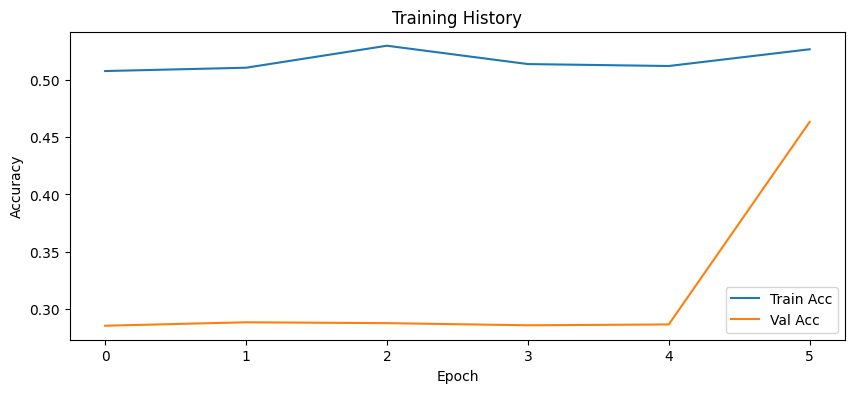

In [11]:
# Plot training history
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training History')
plt.legend()
plt.show()

In [12]:
# Save the trained model
MODEL_DIR = Path.cwd().parent / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / 'ppg_af_lstm.keras'
model.save(MODEL_PATH)
print(f"Model saved successfully to {MODEL_PATH}!")


Model saved successfully to d:\Project Repos\PPG-Arrhythmia-Detection\models\ppg_af_lstm.keras!


## 6. Feature-Based Random Forest Model
This section builds hand-engineered rhythm and signal features for each window, then trains a Random Forest classifier on those features. In this project, this becomes the main practical model because it performs much better than the LSTM baseline.

In [13]:
# Build feature vectors from each window.
# These features emphasize pulse irregularity, which is often important for AF detection.
def extract_window_features(window, fs=125):
    signal = np.asarray(window, dtype=float).reshape(-1)
    peaks, ibi, _ = detect_beats(signal, fs=fs)
    diff_ibi = np.diff(ibi) if len(ibi) > 1 else np.array([])
    return {
        'signal_mean': float(np.mean(signal)),
        'signal_std': float(np.std(signal)),
        'signal_range': float(np.max(signal) - np.min(signal)),
        'signal_energy': float(np.mean(signal ** 2)),
        'peak_count': int(len(peaks)),
        'ibi_mean': float(np.mean(ibi)) if len(ibi) else 0.0,
        'ibi_std': float(np.std(ibi)) if len(ibi) else 0.0,
        'ibi_rmssd': float(np.sqrt(np.mean(diff_ibi ** 2))) if len(diff_ibi) else 0.0,
        'ibi_cv': float(np.std(ibi) / np.mean(ibi)) if len(ibi) and np.mean(ibi) > 0 else 0.0,
    }

X_train_feat = pd.DataFrame([extract_window_features(window[:, 0]) for window in X_train])
X_test_feat = pd.DataFrame([extract_window_features(window[:, 0]) for window in X_test])

print('Feature matrix shape (train):', X_train_feat.shape)
print('Feature matrix shape (test):', X_test_feat.shape)
X_train_feat.head()


Feature matrix shape (train): (13384, 9)
Feature matrix shape (test): (3346, 9)


,signal_mean,signal_std,signal_range,signal_energy,peak_count,ibi_mean,ibi_std,ibi_rmssd,ibi_cv
0,-0.018006,1.082027,3.950132,1.171108,9,0.541000,0.006856,0.013180,0.012672
1,0.011496,1.072258,3.848219,1.149869,9,0.543000,0.002646,0.004276,0.004872
2,-0.004062,1.063283,3.893126,1.130588,9,0.545000,0.004796,0.009562,0.008800
3,0.004161,1.059423,4.231371,1.122394,8,0.622857,0.193349,0.321181,0.310423
4,0.021162,1.031562,4.230278,1.064568,8,0.627429,0.191612,0.321596,0.305392


### Random Forest On Engineered Features
The Random Forest is the main deployment model for the app. If it outperforms the LSTM baseline, we save it and use it for feature-based inference in Streamlit.

Random Forest Classification Report:
              precision    recall  f1-score   support

      Non-AF       0.93      0.84      0.88      1434
          AF       0.89      0.95      0.92      1912

    accuracy                           0.90      3346
   macro avg       0.91      0.90      0.90      3346
weighted avg       0.90      0.90      0.90      3346



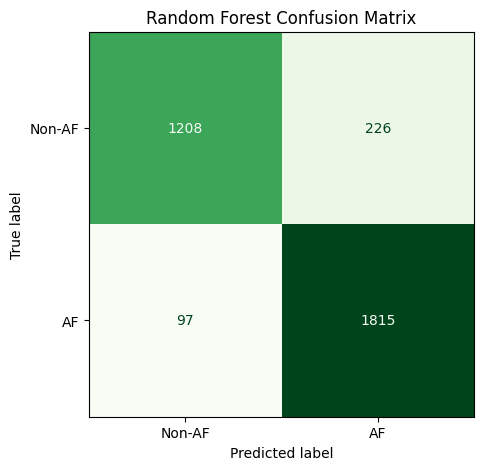

Random Forest ROC-AUC: 0.943
Random Forest PR-AUC: 0.928


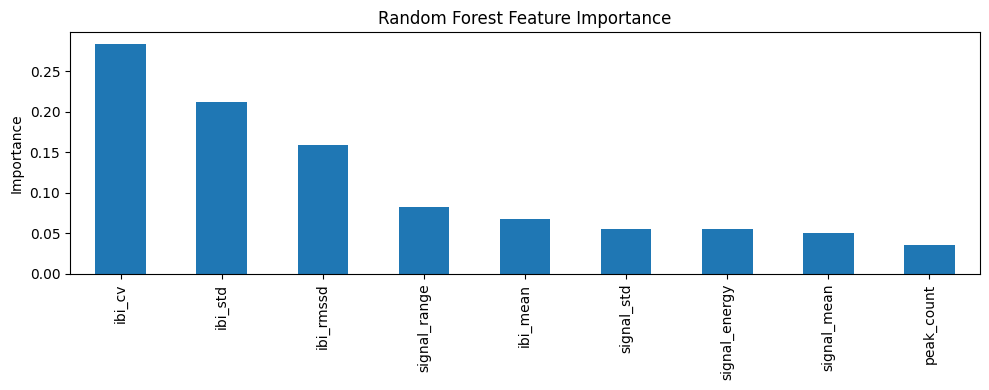

Random Forest model saved to d:\Project Repos\PPG-Arrhythmia-Detection\models\ppg_af_rf.joblib!


In [14]:
# Train, evaluate, and save a Random Forest on the engineered features.
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf_model.fit(X_train_feat, y_train)
rf_pred = rf_model.predict(X_test_feat)
rf_prob = rf_model.predict_proba(X_test_feat)[:, 1]

print('Random Forest Classification Report:')
print(classification_report(y_test, rf_pred, target_names=['Non-AF', 'AF'], zero_division=0))

rf_cm = confusion_matrix(y_test, rf_pred)
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Non-AF', 'AF'])
fig, ax = plt.subplots(figsize=(5, 5))
rf_disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Random Forest Confusion Matrix')
plt.show()

rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)
print(f'Random Forest ROC-AUC: {rf_roc_auc:.3f}')
print(f'Random Forest PR-AUC: {rf_pr_auc:.3f}')

feature_importance = pd.Series(rf_model.feature_importances_, index=X_train_feat.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
feature_importance.plot(kind="bar")
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

MODEL_DIR = Path.cwd().parent / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RF_MODEL_PATH = MODEL_DIR / "ppg_af_rf.joblib"
joblib.dump(rf_model, RF_MODEL_PATH)
print(f"Random Forest model saved to {RF_MODEL_PATH}!")


### SHAP Explanation For The Random Forest Model
This section uses SHAP to explain which engineered features push the Random Forest toward AF or Non-AF. Because this is a tree model, the SHAP values are usually more stable and easier to interpret than the sequence-level SHAP plots from the LSTM baseline.

Explaining 200 Random Forest test windows with SHAP.


C:\Users\User\AppData\Local\Temp\ipykernel_24684\1236034807.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_shap_values, X_rf_explain, show=False)


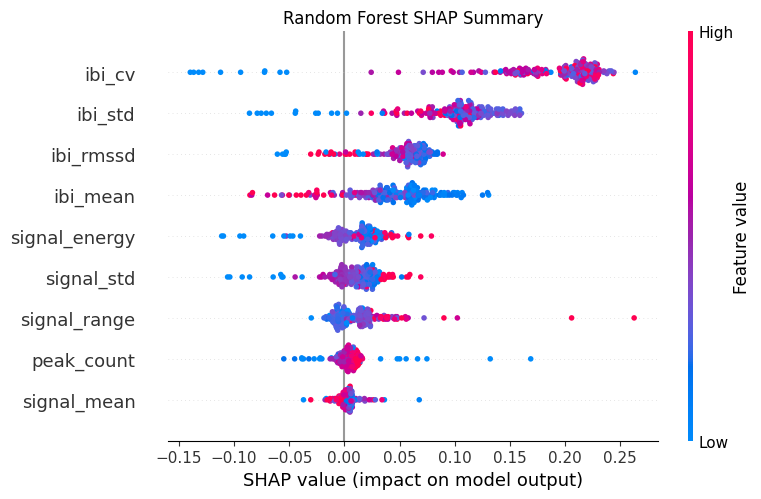

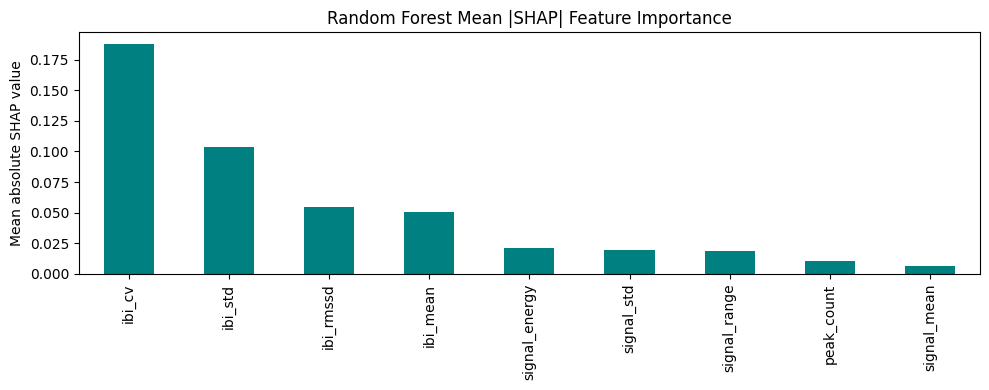

,feature_value,shap_value
ibi_cv,0.373643,0.147153
ibi_std,0.215816,0.080304
ibi_mean,0.577600,0.072502
ibi_rmssd,0.387856,0.052080
signal_range,5.144273,0.027489
signal_energy,0.954308,-0.010712
signal_std,0.976509,-0.010475
peak_count,6.000000,-0.005430
signal_mean,0.027152,-0.003270


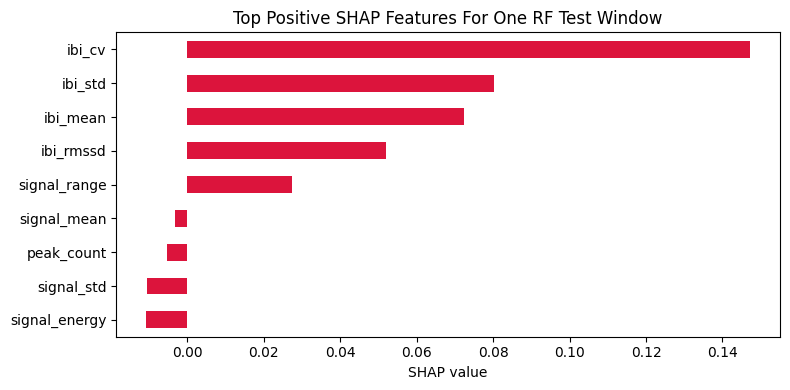

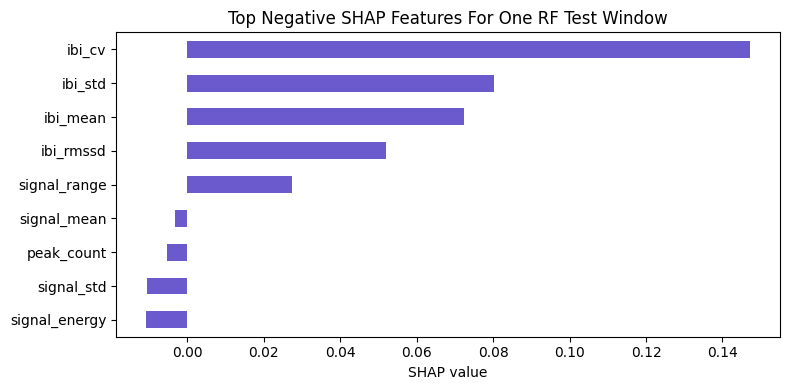

In [15]:
# Explain the Random Forest with SHAP on a manageable subset of the test feature matrix.
rf_explain_size = min(200, len(X_test_feat))
X_rf_explain = X_test_feat.iloc[:rf_explain_size].copy()

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_raw = rf_explainer.shap_values(X_rf_explain)

# SHAP can return different shapes depending on the library version, so normalize it here.
if isinstance(rf_shap_raw, list):
    rf_shap_values = rf_shap_raw[1] if len(rf_shap_raw) > 1 else rf_shap_raw[0]
elif isinstance(rf_shap_raw, np.ndarray) and rf_shap_raw.ndim == 3:
    rf_shap_values = rf_shap_raw[:, :, 1]
else:
    rf_shap_values = rf_shap_raw

print(f'Explaining {len(X_rf_explain)} Random Forest test windows with SHAP.')

# Global SHAP summary: which features matter most across many test windows.
plt.figure(figsize=(10, 5))
shap.summary_plot(rf_shap_values, X_rf_explain, show=False)
plt.title('Random Forest SHAP Summary')
plt.tight_layout()
plt.show()

# Mean absolute SHAP values give a simple ranked importance view.
rf_mean_abs_shap = pd.Series(np.abs(rf_shap_values).mean(axis=0), index=X_rf_explain.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
rf_mean_abs_shap.plot(kind='bar', color='teal')
plt.title('Random Forest Mean |SHAP| Feature Importance')
plt.ylabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()

# Local explanation for one test window.
rf_example_idx = 0
rf_example_features = X_rf_explain.iloc[rf_example_idx]
rf_example_shap = pd.Series(rf_shap_values[rf_example_idx], index=X_rf_explain.columns).sort_values()

display(pd.DataFrame({
    'feature_value': rf_example_features[rf_example_shap.index],
    'shap_value': rf_example_shap,
}).sort_values('shap_value', key=np.abs, ascending=False).head(10))

plt.figure(figsize=(8, 4))
rf_example_shap.tail(10).plot(kind='barh', color='crimson')
plt.title('Top Positive SHAP Features For One RF Test Window')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
rf_example_shap.head(10).plot(kind='barh', color='slateblue')
plt.title('Top Negative SHAP Features For One RF Test Window')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()
